# HumanifyMe — proof figures

Regenerates every figure on `docs/proof/` from the structured eval output in `evals/results/ablation-data.json` (produced by `evals/harness/runAblation.ts`, which makes real Anthropic calls). Run top to bottom to reproduce.

Method: four writers of distinct register (casual/lowercase, formal/sentence-case, terse/technical, warm/enthusiastic) each have a small voice-memory corpus. The same generic-AI drafts are rewritten for each writer with retrieval ON and OFF, then scored deterministically (stylometric distance, casing fidelity, AI-smell) and judged blind by an LLM ("which rewrite sounds more like this person?") with position-bias cancellation.

In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 130, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'figure.autolayout': True})
ON, OFF, GOOD, WARN = '#2563eb', '#cbd5e1', '#16a34a', '#dc2626'

DATA = json.load(open('../results/ablation-data.json', encoding='utf-8'))
FIGDIR = '../../docs/proof/figures'
os.makedirs(FIGDIR, exist_ok=True)
writers = DATA['writers']
letters = [l.split('\u00b7')[0].strip() for l in DATA['labels']]
regs = [w['register'] for w in writers]
ticks = [f"{a}\n{r}" for a, r in zip(letters, regs)]
def save(name):
    plt.savefig(f'{FIGDIR}/{name}', bbox_inches='tight'); print('wrote', name)
print('writers:', letters, '| accuracy:', DATA['classificationAccuracy'])

writers: ['A', 'B', 'C', 'D'] | accuracy: 0.85


## 1. Capitalization register matches the writer
Each rewrite's sentence-initial capitalization rate, against the writer's true register. Lowercase writers land near 0, sentence-case writers near 1.

wrote register-adaptation.png


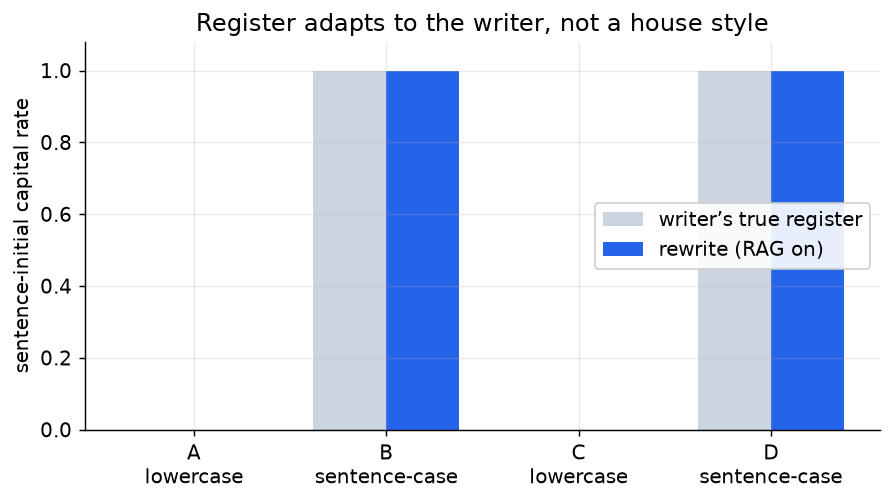

In [2]:
ach = [w['ragOn']['casing'] for w in writers]
tgt = [w['targetCasing'] for w in writers]
x = np.arange(len(writers)); bw = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - bw/2, tgt, bw, label='writer\u2019s true register', color=OFF)
ax.bar(x + bw/2, ach, bw, label='rewrite (RAG on)', color=ON)
ax.set_xticks(x); ax.set_xticklabels(ticks); ax.set_ylim(0, 1.08)
ax.set_ylabel('sentence-initial capital rate')
ax.set_title('Register adapts to the writer, not a house style')
ax.legend(loc='center right', framealpha=0.9)
save('register-adaptation.png'); plt.show()

## 2. Nearest-author confusion matrix
For each retrieval-grounded rewrite, which writer's voice is it stylometrically closest to? A correct rewrite lands closest to its own writer (the diagonal).

wrote register-confusion-matrix.png


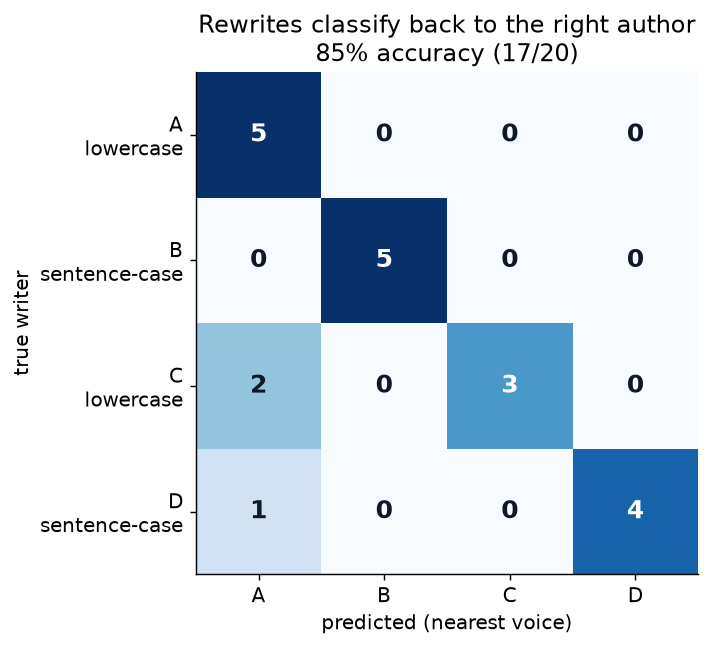

In [3]:
cm = np.array(DATA['confusionMatrix'], dtype=float)
acc = DATA['classificationAccuracy']
fig, ax = plt.subplots(figsize=(5.6, 5.2))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
ax.set_xticks(range(len(letters))); ax.set_yticks(range(len(letters)))
ax.set_xticklabels(letters); ax.set_yticklabels(ticks)
ax.set_xlabel('predicted (nearest voice)'); ax.set_ylabel('true writer')
ax.grid(False)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        v = int(cm[i, j])
        ax.text(j, i, v, ha='center', va='center',
                color='white' if v > cm.max()/2 else '#0f172a', fontsize=14, fontweight='bold')
ax.set_title(f'Rewrites classify back to the right author\n{acc*100:.0f}% accuracy ({int(cm.trace())}/{int(cm.sum())})')
save('register-confusion-matrix.png'); plt.show()

## 3. Stylometric distance: retrieval on vs off
Lower is closer to the writer. Retrieval helps for three of four writers; we report the one it does not help (B) rather than hide it. The metric is noisy run to run.

wrote stylometric-distance.png


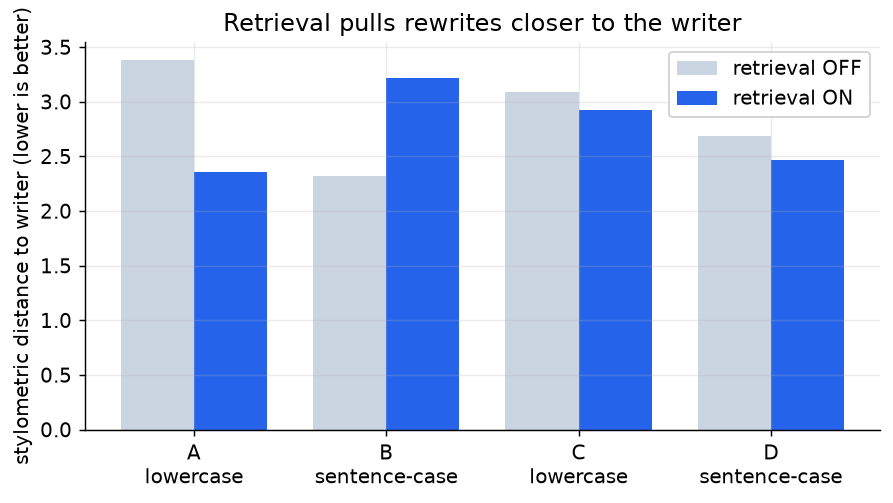

In [4]:
on = [w['ragOn']['dist'] for w in writers]
off = [w['ragOff']['dist'] for w in writers]
x = np.arange(len(writers)); bw = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - bw/2, off, bw, label='retrieval OFF', color=OFF)
ax.bar(x + bw/2, on, bw, label='retrieval ON', color=ON)
ax.set_xticks(x); ax.set_xticklabels(ticks)
ax.set_ylabel('stylometric distance to writer (lower is better)')
ax.set_title('Retrieval pulls rewrites closer to the writer')
ax.legend(framealpha=0.9)
save('stylometric-distance.png'); plt.show()

## 4. Blind-judge preference for the retrieval-grounded rewrite
An LLM judge, shown the writer's real messages and two unlabeled rewrites, picks which sounds more like the same person. Slot order is alternated to cancel position bias. 50% is chance.

wrote judge-preference.png


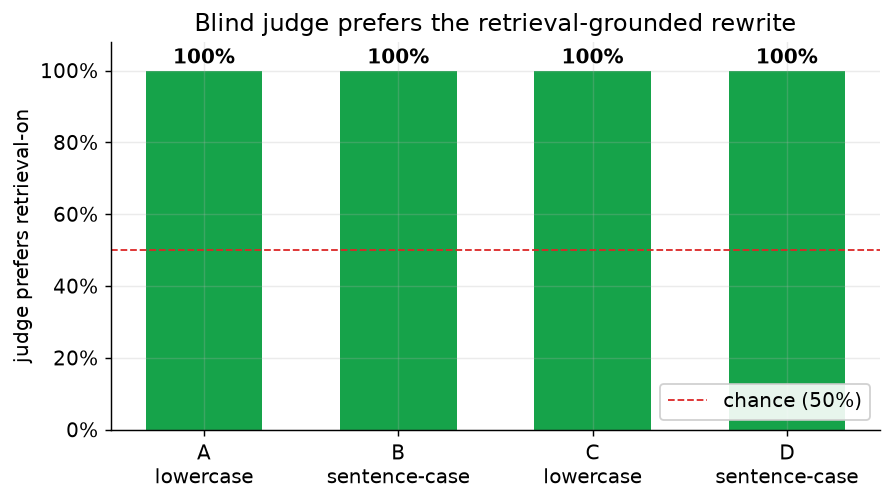

In [5]:
pref = [w['ragOn']['judgePrefersOn'] for w in writers]
x = np.arange(len(writers))
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(x, pref, 0.6, color=GOOD)
ax.axhline(0.5, ls='--', lw=1, color=WARN, label='chance (50%)')
ax.set_xticks(x); ax.set_xticklabels(ticks); ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylabel('judge prefers retrieval-on')
for b, p in zip(bars, pref):
    ax.text(b.get_x()+b.get_width()/2, p+0.02, f'{p*100:.0f}%', ha='center', fontweight='bold')
ax.set_title('Blind judge prefers the retrieval-grounded rewrite')
ax.legend(loc='lower right', framealpha=0.9)
save('judge-preference.png'); plt.show()

## 5. Redaction coverage (deterministic privacy proof)
The redactor masks every labeled secret class with zero false positives on 20 plain-prose paragraphs. No LLM involved; this is from the golden test set.

wrote redaction-coverage.png


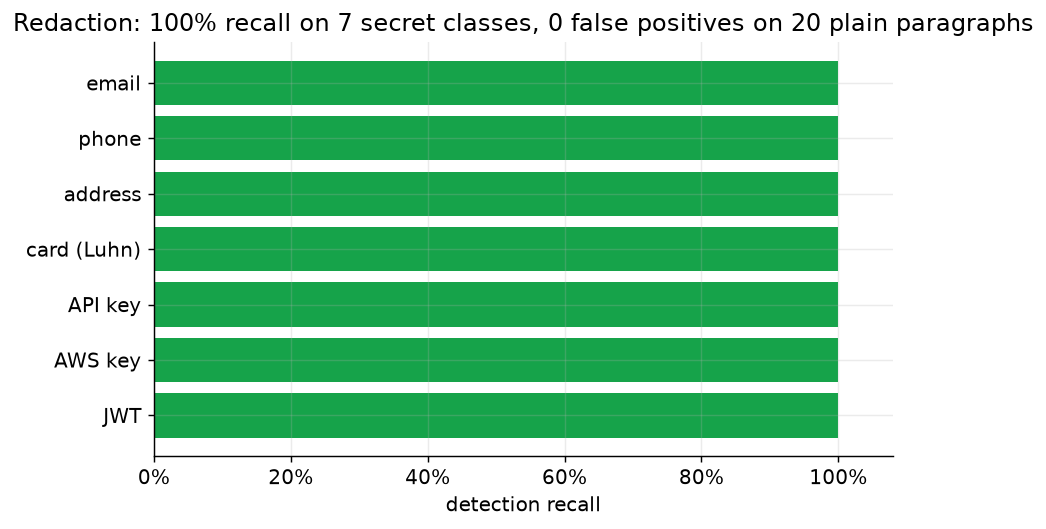

In [6]:
r = DATA['redaction']
classes = r['classes']
y = np.arange(len(classes))
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh(y, [1.0]*len(classes), color=GOOD)
ax.set_yticks(y); ax.set_yticklabels(classes); ax.invert_yaxis()
ax.set_xlim(0, 1.08); ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('detection recall')
ax.set_title(f"Redaction: 100% recall on {len(classes)} secret classes, "
             f"{r['falsePositives']} false positives on {r['plainParagraphs']} plain paragraphs")
save('redaction-coverage.png'); plt.show()